HSI-TIFF ResNet50 Pretrained Feature Extraction + Optimized LDA Clustering + Quality Evaluation
Device: cuda
Loading ImageNet pretrained ResNet50...


Extracting ResNet50 features: 100%|██████████████████████████████████████████████████| 148/148 [00:01<00:00, 82.86it/s]


Feature shape: (148, 2048) (2048-dim)

Starting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering...
  PCA denoising dimension: 2048 -> 23 (retained 95% variance)
  Iteration 1/20, label changes: 91
  Iteration 2/20, label changes: 0
  Converged after 2 iterations.
  KNN smoothing corrected 2 outlier samples

  Clustering quality metrics:
    Silhouette Score: 0.9030  (ideal > 0.5, closer to 1 is better)
    CH Index: 377.14    (higher is better)
    DB Index: 0.4580  (lower is better, ideal < 1)

Monotonic cluster label statistics:
  Monotonic cluster 1: 58 images
  Monotonic cluster 2: 55 images
  Monotonic cluster 3: 35 images

Mean label per class:
   Monotonic Cluster  Matched_Samples  Mean_Label  Median_Label  Min_Label  \
0                  1               58      8.8400        10.325       1.78   
1                  2               55     13.5196        13.820       2.04   
2                  3               35     15.3163        15.100      11.

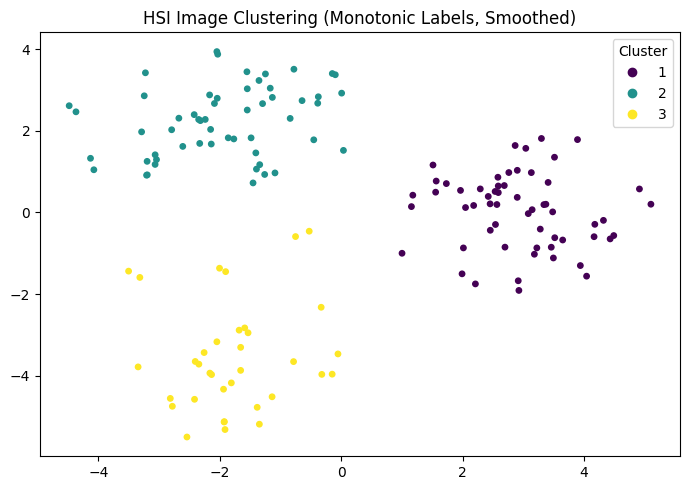

Clustering plot saved: clustering_result.png

All completed!
Clustering results: E:\YRH-HSI\python data\MUST\must\clustering_results_simple.xlsx
Comparison results: E:\YRH-HSI\python data\MUST\must\clustering_label_comparison_simple.xlsx
Features saved: resnet50_features.pkl
Clustering plot: clustering_result.png


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import warnings
warnings.filterwarnings("ignore")

import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
from torchvision import transforms, models
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import matplotlib.pyplot as plt

CURRENT_DIR = os.getcwd()

IMAGE_FOLDER = os.path.join(CURRENT_DIR, "HSI-TIFF")
LABEL_PATH = os.path.join(CURRENT_DIR, "label-1.xlsx")
EXCEL_OUTPUT_DIR = CURRENT_DIR

CLUSTER_OUTPUT_PATH = os.path.join(EXCEL_OUTPUT_DIR, "clustering_results_simple.xlsx")
COMPARE_OUTPUT_PATH = os.path.join(EXCEL_OUTPUT_DIR, "clustering_label_comparison_simple.xlsx")

N_CLUSTERS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def normalize_sample_id(value):
    text = str(value).strip()
    text = os.path.basename(text)
    text = re.sub(r"\.(tiff|tif)$", "", text, flags=re.IGNORECASE)

    if re.fullmatch(r"\d+\.0", text):
        text = text[:-2]

    return text

def sample_sort_key(value):
    sid = normalize_sample_id(value)

    if sid == "1":
        return 0
    if sid == "2":
        return 1

    match = re.fullmatch(r"(\d+)(\.1)?", sid)

    if match:
        num = int(match.group(1))
        suffix = match.group(2)

        if 3 <= num <= 75:
            base = 2 + (num - 3) * 2
            return base + (1 if suffix else 0)

    return 999999

def load_label_table():
    label_df = pd.read_excel(LABEL_PATH, header=None)
    label_df = label_df.iloc[:, :2].copy()
    label_df.columns = ["Sample ID", "label"]

    label_df["Sample ID"] = label_df["Sample ID"].apply(normalize_sample_id)
    label_df["label"] = pd.to_numeric(label_df["label"], errors="coerce")

    label_df = label_df.dropna(subset=["Sample ID", "label"])
    label_df = label_df.drop_duplicates(subset=["Sample ID"], keep="first")

    return label_df

def knn_smooth_labels(features, labels, n_neighbors=7):
    n_neighbors = min(n_neighbors, len(labels) - 1)

    nbrs = NearestNeighbors(
        n_neighbors=n_neighbors + 1,
        metric="cosine"
    ).fit(features)

    _, indices = nbrs.kneighbors(features)
    neighbor_indices = indices[:, 1:]

    smoothed_labels = labels.copy()

    for i in range(len(labels)):
        neighbor_labels = labels[neighbor_indices[i]]
        unique, counts = np.unique(neighbor_labels, return_counts=True)
        majority_label = unique[np.argmax(counts)]

        if np.max(counts) > n_neighbors // 2 and majority_label != labels[i]:
            smoothed_labels[i] = majority_label

    changed = np.sum(smoothed_labels != labels)
    print(f"  KNN smoothing corrected {changed} outlier samples")

    return smoothed_labels

def extract_pretrained_features():
    print("Loading ImageNet pretrained ResNet50...")

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Identity()
    model = model.to(DEVICE)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    paths = [
        os.path.join(IMAGE_FOLDER, f)
        for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith((".tiff", ".tif"))
    ]

    paths.sort(key=sample_sort_key)

    feats = []

    with torch.no_grad():
        for p in tqdm(paths, desc="Extracting ResNet50 features"):
            img = Image.open(p).convert("RGB")
            x = transform(img).unsqueeze(0).to(DEVICE)
            feat = model(x)
            feats.append(feat.cpu().numpy())

    feat_mat = np.vstack(feats)

    joblib.dump(
        {
            "features": feat_mat,
            "paths": paths
        },
        os.path.join(CURRENT_DIR, "resnet50_features.pkl")
    )

    print(f"Feature shape: {feat_mat.shape} (2048-dim)")

    return feat_mat, paths

def compare_with_label_and_make_monotonic(result_df):
    label_df = load_label_table()

    compare_df = result_df.merge(label_df, on="Sample ID", how="left")
    matched_df = compare_df.dropna(subset=["label"]).copy()

    if matched_df.empty:
        raise RuntimeError("No matched samples between clustering results and labels. Please check sample IDs.")

    cluster_stats = (
        matched_df.groupby("Original Cluster")["label"]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
        .sort_values(["mean", "median", "Original Cluster"])
        .reset_index(drop=True)
    )

    cluster_stats = cluster_stats.rename(columns={
        "count": "Matched Samples",
        "mean": "Mean Label",
        "median": "Median Label",
        "min": "Min Label",
        "max": "Max Label"
    })

    cluster_stats["Mean Label"] = cluster_stats["Mean Label"].round(4)
    cluster_stats["Median Label"] = cluster_stats["Median Label"].round(4)
    cluster_stats["Min Label"] = cluster_stats["Min Label"].round(4)
    cluster_stats["Max Label"] = cluster_stats["Max Label"].round(4)

    cluster_mapping = {
        int(row["Original Cluster"]): idx + 1
        for idx, row in cluster_stats.iterrows()
    }

    compare_df["Monotonic Cluster"] = compare_df["Original Cluster"].map(cluster_mapping)

    matched_for_metric = compare_df.dropna(
        subset=["label", "Monotonic Cluster"]
    ).copy()

    label_mean_by_class = (
        matched_for_metric
        .groupby("Monotonic Cluster")
        .agg(
            Matched_Samples=("label", "count"),
            Mean_Label=("label", "mean"),
            Median_Label=("label", "median"),
            Min_Label=("label", "min"),
            Max_Label=("label", "max")
        )
        .reset_index()
        .sort_values("Monotonic Cluster")
    )

    label_mean_by_class["Mean_Label"] = label_mean_by_class["Mean_Label"].round(4)
    label_mean_by_class["Median_Label"] = label_mean_by_class["Median_Label"].round(4)
    label_mean_by_class["Min_Label"] = label_mean_by_class["Min_Label"].round(4)
    label_mean_by_class["Max_Label"] = label_mean_by_class["Max_Label"].round(4)

    compare_df = compare_df.merge(
        label_mean_by_class[["Monotonic Cluster", "Mean_Label"]],
        on="Monotonic Cluster",
        how="left"
    )

    compare_df = compare_df.rename(columns={
        "Mean_Label": "Mean Label of Class"
    })

    spearman_corr = matched_for_metric["label"].rank().corr(
        matched_for_metric["Monotonic Cluster"].rank()
    )

    label_sorted = matched_for_metric.sort_values(
        by=["label", "Sample Order"]
    )

    monotonic_breaks = (
        label_sorted["Monotonic Cluster"].diff().dropna() < 0
    ).sum()

    metric_df = pd.DataFrame({
        "Metric": [
            "Matched Samples",
            "Unmatched Samples",
            "Spearman Monotonic Correlation",
            "Adjacent Monotonic Violations (by label asc)"
        ],
        "Value": [
            len(matched_for_metric),
            compare_df["label"].isna().sum(),
            spearman_corr,
            int(monotonic_breaks)
        ]
    })

    cluster_stats["Monotonic Cluster"] = cluster_stats["Original Cluster"].map(
        cluster_mapping
    )

    cluster_stats = cluster_stats.sort_values("Monotonic Cluster")

    return compare_df, cluster_stats, metric_df, label_mean_by_class

def lda_clustering(features, img_paths):
    print("\nStarting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering...")

    pca = PCA(n_components=0.95, random_state=42)
    features_pca = pca.fit_transform(features)

    print(
        f"  PCA denoising dimension: {features.shape[1]} -> {features_pca.shape[1]}"
        f" (retained 95% variance)"
    )

    features_norm = normalize(features_pca, norm="l2")

    km_init = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init=20
    )

    pseudo_labels = km_init.fit_predict(features_norm)

    max_iter = 20
    tol = 0

    lda = LDA(n_components=2)

    km = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init=20
    )

    for iter_idx in range(max_iter):
        features_lda = lda.fit_transform(features_norm, pseudo_labels)
        new_labels = km.fit_predict(features_lda)

        changed_count = np.sum(new_labels != pseudo_labels)

        print(f"  Iteration {iter_idx + 1}/{max_iter}, label changes: {changed_count}")

        if changed_count <= tol:
            print(f"  Converged after {iter_idx + 1} iterations.")
            break

        pseudo_labels = new_labels

    else:
        print(f"  Reached maximum iterations {max_iter}, stopping.")

    raw_clusters = knn_smooth_labels(
        features_lda,
        pseudo_labels,
        n_neighbors=7
    )

    sil_score = silhouette_score(
        features_lda,
        raw_clusters,
        metric="cosine"
    )

    ch_score = calinski_harabasz_score(
        features_lda,
        raw_clusters
    )

    db_score = davies_bouldin_score(
        features_lda,
        raw_clusters
    )

    quality_metrics = pd.DataFrame({
        "Metric Name": [
            "Silhouette Score",
            "Calinski-Harabasz Index",
            "Davies-Bouldin Index"
        ],
        "Value": [
            sil_score,
            ch_score,
            db_score
        ],
        "Evaluation Criterion": [
            "Range [-1, 1], higher indicates better compactness and separation",
            "Higher values indicate larger inter-cluster differences",
            "Lower values indicate more compact clusters"
        ]
    })

    print("\n  Clustering quality metrics:")
    print(f"    Silhouette Score: {sil_score:.4f}  (ideal > 0.5, closer to 1 is better)")
    print(f"    CH Index: {ch_score:.2f}    (higher is better)")
    print(f"    DB Index: {db_score:.4f}  (lower is better, ideal < 1)")

    os.makedirs(EXCEL_OUTPUT_DIR, exist_ok=True)

    result_df = pd.DataFrame({
        "Sample ID": [normalize_sample_id(p) for p in img_paths],
        "File Name": [os.path.basename(p) for p in img_paths],
        "File Path": img_paths,
        "Sample Order": [sample_sort_key(p) for p in img_paths],
        "Original Cluster": raw_clusters,
        "LDA1": features_lda[:, 0],
        "LDA2": features_lda[:, 1]
    })

    compare_df, cluster_stats, metric_df, label_mean_by_class = (
        compare_with_label_and_make_monotonic(result_df)
    )

    result_df["Monotonic Cluster"] = compare_df["Monotonic Cluster"].values
    result_df["Mean Label of Class"] = compare_df["Mean Label of Class"].values

    result_df.to_excel(CLUSTER_OUTPUT_PATH, index=False)

    with pd.ExcelWriter(COMPARE_OUTPUT_PATH, engine="openpyxl") as writer:
        compare_df.to_excel(writer, sheet_name="Comparison Results", index=False)
        cluster_stats.to_excel(writer, sheet_name="Cluster Statistics", index=False)
        label_mean_by_class.to_excel(writer, sheet_name="Mean Label per Class", index=False)
        metric_df.to_excel(writer, sheet_name="Monotonicity Metrics", index=False)
        quality_metrics.to_excel(writer, sheet_name="Clustering Quality Metrics", index=False)

    joblib.dump(
        {
            "features_lda": features_lda,
            "raw_cluster_labels": raw_clusters,
            "monotonic_cluster_labels": result_df["Monotonic Cluster"].values,
            "class_label_mean": result_df["Mean Label of Class"].values,
            "paths": img_paths,
            "metrics": quality_metrics,
            "label_mean_by_class": label_mean_by_class
        },
        os.path.join(CURRENT_DIR, "final_clustering_result.pkl")
    )

    unique, cnt = np.unique(result_df["Monotonic Cluster"], return_counts=True)

    print("\nMonotonic cluster label statistics:")
    for label, count in zip(unique, cnt):
        print(f"  Monotonic cluster {int(label)}: {count} images")

    print("\nMean label per class:")
    print(label_mean_by_class)

    print(f"\nClustering results saved to: {CLUSTER_OUTPUT_PATH}")
    print(f"Clustering vs label comparison saved to: {COMPARE_OUTPUT_PATH}")

    return features_lda, result_df["Monotonic Cluster"].values

def visualize(features_lda, clusters):
    plt.figure(figsize=(7, 5))

    scatter = plt.scatter(
        features_lda[:, 0],
        features_lda[:, 1],
        c=clusters,
        cmap="viridis",
        s=15
    )

    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.title("HSI Image Clustering (Monotonic Labels, Smoothed)")
    plt.tight_layout()
    plt.savefig(os.path.join(CURRENT_DIR, "clustering_result.png"), dpi=300)
    plt.show()

    print("Clustering plot saved: clustering_result.png")

if __name__ == "__main__":
    print("=" * 60)
    print("HSI-TIFF ResNet50 Pretrained Feature Extraction + Optimized LDA Clustering + Quality Evaluation")
    print(f"Device: {DEVICE}")
    print("=" * 60)

    feat_mat, img_paths = extract_pretrained_features()

    feat_lda, cluster_labels = lda_clustering(
        feat_mat,
        img_paths
    )

    visualize(
        feat_lda,
        cluster_labels
    )

    print("\n" + "=" * 60)
    print("All completed!")
    print(f"Clustering results: {CLUSTER_OUTPUT_PATH}")
    print(f"Comparison results: {COMPARE_OUTPUT_PATH}")
    print("Features saved: resnet50_features.pkl")
    print("Clustering plot: clustering_result.png")
    print("=" * 60)

HSI-TIFF ResNet50 Pretrained Feature Extraction + Optimized LDA Clustering + Quality Evaluation
Device: cuda
Loading ImageNet pretrained ResNet50...


Extracting ResNet50 features: 100%|█████████████████████████████████████████████████| 148/148 [00:01<00:00, 121.22it/s]


Feature shape: (148, 2048) (2048-dim)

Starting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering (k=3)...
  PCA denoising dimension: 2048 -> 23 (retained 95% variance)
  Iteration 1/20, label changes: 91
  Iteration 2/20, label changes: 0
  Converged after 2 iterations.
  KNN smoothing corrected 2 outlier samples

  Clustering quality metrics:
    Silhouette Score: 0.9030  (ideal > 0.5, closer to 1 is better)
    CH Index: 377.14    (higher is better)
    DB Index: 0.4580  (lower is better, ideal < 1)

Monotonic cluster label statistics:
  Monotonic cluster 1: 58 images
  Monotonic cluster 2: 55 images
  Monotonic cluster 3: 35 images

Mean label per class:
   monotonic_cluster  matched_samples  label_mean  label_median  label_min  \
0                  1               58      8.8400        10.325       1.78   
1                  2               55     13.5196        13.820       2.04   
2                  3               35     15.3163        15.100   

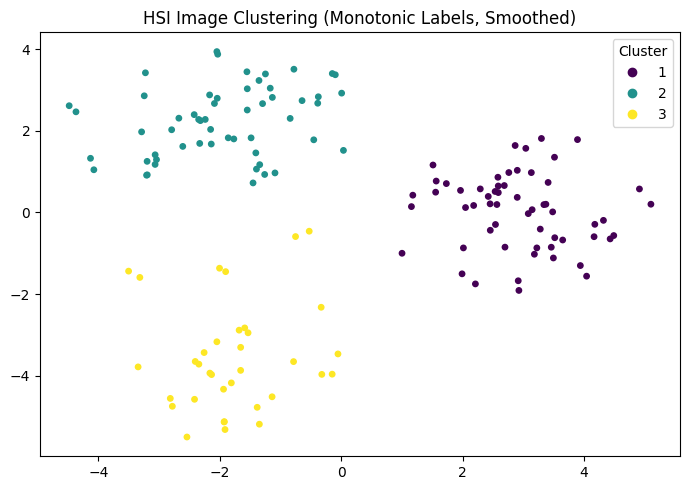

Clustering plot saved: clustering_result.png

Evaluating k = 4 ...

Starting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering (k=4)...
  PCA denoising dimension: 2048 -> 23 (retained 95% variance)
  Iteration 1/20, label changes: 86
  Iteration 2/20, label changes: 66
  Iteration 3/20, label changes: 145
  Iteration 4/20, label changes: 1
  Iteration 5/20, label changes: 76
  Iteration 6/20, label changes: 0
  Converged after 6 iterations.
  KNN smoothing corrected 0 outlier samples

  Clustering quality metrics:
    Silhouette Score: 0.8877  (ideal > 0.5, closer to 1 is better)
    CH Index: 440.96    (higher is better)
    DB Index: 0.4486  (lower is better, ideal < 1)

Evaluating k = 5 ...

Starting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering (k=5)...
  PCA denoising dimension: 2048 -> 23 (retained 95% variance)
  Iteration 1/20, label changes: 148
  Iteration 2/20, label changes: 87
  Iteration 3/20, label cha

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
from torchvision import transforms, models
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import matplotlib.pyplot as plt

CURRENT_DIR = os.getcwd()

IMAGE_FOLDER = os.path.join(CURRENT_DIR, "HSI-TIFF")
LABEL_PATH = os.path.join(CURRENT_DIR, "label-1.xlsx")
EXCEL_OUTPUT_DIR = CURRENT_DIR

CLUSTER_OUTPUT_PATH = os.path.join(EXCEL_OUTPUT_DIR, "clustering_results_simple.xlsx")
COMPARE_OUTPUT_PATH = os.path.join(EXCEL_OUTPUT_DIR, "cluster_label_comparison_simple.xlsx")

N_CLUSTERS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def normalize_sample_id(value):
    text = str(value).strip()
    text = os.path.basename(text)
    text = re.sub(r"\.(tiff|tif)$", "", text, flags=re.IGNORECASE)
    if re.fullmatch(r"\d+\.0", text):
        text = text[:-2]
    return text

def sample_sort_key(value):
    sid = normalize_sample_id(value)
    if sid == "1":
        return 0
    if sid == "2":
        return 1
    match = re.fullmatch(r"(\d+)(\.1)?", sid)
    if match:
        num = int(match.group(1))
        suffix = match.group(2)
        if 3 <= num <= 75:
            base = 2 + (num - 3) * 2
            return base + (1 if suffix else 0)
    return 999999

def load_label_table():
    label_df = pd.read_excel(LABEL_PATH, header=None)
    label_df = label_df.iloc[:, :2].copy()
    label_df.columns = ["sample_id", "label"]
    label_df["sample_id"] = label_df["sample_id"].apply(normalize_sample_id)
    label_df["label"] = pd.to_numeric(label_df["label"], errors="coerce")
    label_df = label_df.dropna(subset=["sample_id", "label"])
    label_df = label_df.drop_duplicates(subset=["sample_id"], keep="first")
    return label_df

def knn_smooth_labels(features, labels, n_neighbors=7):
    n_neighbors = min(n_neighbors, len(labels) - 1)
    nbrs = NearestNeighbors(
        n_neighbors=n_neighbors + 1,
        metric="cosine"
    ).fit(features)
    _, indices = nbrs.kneighbors(features)
    neighbor_indices = indices[:, 1:]
    smoothed_labels = labels.copy()
    for i in range(len(labels)):
        neighbor_labels = labels[neighbor_indices[i]]
        unique, counts = np.unique(neighbor_labels, return_counts=True)
        majority_label = unique[np.argmax(counts)]
        if np.max(counts) > n_neighbors // 2 and majority_label != labels[i]:
            smoothed_labels[i] = majority_label
    changed = np.sum(smoothed_labels != labels)
    print(f"  KNN smoothing corrected {changed} outlier samples")
    return smoothed_labels

def extract_pretrained_features():
    print("Loading ImageNet pretrained ResNet50...")
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Identity()
    model = model.to(DEVICE)
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
    paths = [
        os.path.join(IMAGE_FOLDER, f)
        for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith((".tiff", ".tif"))
    ]
    paths.sort(key=sample_sort_key)
    feats = []
    with torch.no_grad():
        for p in tqdm(paths, desc="Extracting ResNet50 features"):
            img = Image.open(p).convert("RGB")
            x = transform(img).unsqueeze(0).to(DEVICE)
            feat = model(x)
            feats.append(feat.cpu().numpy())
    feat_mat = np.vstack(feats)
    joblib.dump(
        {
            "features": feat_mat,
            "paths": paths
        },
        os.path.join(CURRENT_DIR, "resnet50_features.pkl")
    )
    print(f"Feature shape: {feat_mat.shape} (2048-dim)")
    return feat_mat, paths

def compare_with_label_and_make_monotonic(result_df):
    label_df = load_label_table()
    compare_df = result_df.merge(label_df, on="sample_id", how="left")
    matched_df = compare_df.dropna(subset=["label"]).copy()
    if matched_df.empty:
        raise RuntimeError("No matched samples between clustering results and labels. Please check sample IDs.")
    cluster_stats = (
        matched_df.groupby("original_cluster")["label"]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
        .sort_values(["mean", "median", "original_cluster"])
        .reset_index(drop=True)
    )
    cluster_stats = cluster_stats.rename(columns={
        "count": "matched_samples",
        "mean": "label_mean",
        "median": "label_median",
        "min": "label_min",
        "max": "label_max"
    })
    cluster_stats["label_mean"] = cluster_stats["label_mean"].round(4)
    cluster_stats["label_median"] = cluster_stats["label_median"].round(4)
    cluster_stats["label_min"] = cluster_stats["label_min"].round(4)
    cluster_stats["label_max"] = cluster_stats["label_max"].round(4)
    cluster_mapping = {
        int(row["original_cluster"]): idx + 1
        for idx, row in cluster_stats.iterrows()
    }
    compare_df["monotonic_cluster"] = compare_df["original_cluster"].map(cluster_mapping)
    matched_for_metric = compare_df.dropna(
        subset=["label", "monotonic_cluster"]
    ).copy()
    label_mean_by_class = (
        matched_for_metric
        .groupby("monotonic_cluster")
        .agg(
            matched_samples=("label", "count"),
            label_mean=("label", "mean"),
            label_median=("label", "median"),
            label_min=("label", "min"),
            label_max=("label", "max")
        )
        .reset_index()
        .sort_values("monotonic_cluster")
    )
    label_mean_by_class["label_mean"] = label_mean_by_class["label_mean"].round(4)
    label_mean_by_class["label_median"] = label_mean_by_class["label_median"].round(4)
    label_mean_by_class["label_min"] = label_mean_by_class["label_min"].round(4)
    label_mean_by_class["label_max"] = label_mean_by_class["label_max"].round(4)
    compare_df = compare_df.merge(
        label_mean_by_class[["monotonic_cluster", "label_mean"]],
        on="monotonic_cluster",
        how="left"
    )
    compare_df = compare_df.rename(columns={
        "label_mean": "class_label_mean"
    })
    spearman_corr = matched_for_metric["label"].rank().corr(
        matched_for_metric["monotonic_cluster"].rank()
    )
    label_sorted = matched_for_metric.sort_values(
        by=["label", "sample_order"]
    )
    monotonic_breaks = (
        label_sorted["monotonic_cluster"].diff().dropna() < 0
    ).sum()
    metric_df = pd.DataFrame({
        "metric": [
            "Matched samples",
            "Unmatched samples",
            "Spearman rank correlation",
            "Monotonic violation count (sorted by label)"
        ],
        "value": [
            len(matched_for_metric),
            compare_df["label"].isna().sum(),
            spearman_corr,
            int(monotonic_breaks)
        ]
    })
    cluster_stats["monotonic_cluster"] = cluster_stats["original_cluster"].map(
        cluster_mapping
    )
    cluster_stats = cluster_stats.sort_values("monotonic_cluster")
    return compare_df, cluster_stats, metric_df, label_mean_by_class

def lda_clustering(features, img_paths, k=None, save_results=True):
    if k is None:
        k = N_CLUSTERS
    print(f"\nStarting PCA denoising + L2 normalization + iterative LDA-KMeans + KNN smoothing clustering (k={k})...")
    pca = PCA(n_components=0.95, random_state=42)
    features_pca = pca.fit_transform(features)
    print(
        f"  PCA denoising dimension: {features.shape[1]} -> {features_pca.shape[1]}"
        f" (retained 95% variance)"
    )
    features_norm = normalize(features_pca, norm="l2")
    km_init = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    pseudo_labels = km_init.fit_predict(features_norm)
    max_iter = 20
    tol = 0
    n_lda_comp = min(2, k - 1)
    lda = LDA(n_components=n_lda_comp)
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    for iter_idx in range(max_iter):
        features_lda = lda.fit_transform(features_norm, pseudo_labels)
        new_labels = km.fit_predict(features_lda)
        changed_count = np.sum(new_labels != pseudo_labels)
        print(f"  Iteration {iter_idx + 1}/{max_iter}, label changes: {changed_count}")
        if changed_count <= tol:
            print(f"  Converged after {iter_idx + 1} iterations.")
            break
        pseudo_labels = new_labels
    else:
        print(f"  Reached maximum iterations {max_iter}, stopping.")
    raw_clusters = knn_smooth_labels(
        features_lda,
        pseudo_labels,
        n_neighbors=7
    )
    sil_score = silhouette_score(
        features_lda,
        raw_clusters,
        metric="cosine"
    )
    ch_score = calinski_harabasz_score(
        features_lda,
        raw_clusters
    )
    db_score = davies_bouldin_score(
        features_lda,
        raw_clusters
    )
    quality_metrics = pd.DataFrame({
        "metric_name": [
            "Silhouette Score",
            "Calinski-Harabasz Index",
            "Davies-Bouldin Index"
        ],
        "value": [
            sil_score,
            ch_score,
            db_score
        ],
        "description": [
            "Range [-1, 1], higher means better cluster cohesion and separation",
            "Higher value means better cluster separation",
            "Lower value means better cluster cohesion"
        ]
    })
    print("\n  Clustering quality metrics:")
    print(f"    Silhouette Score: {sil_score:.4f}  (ideal > 0.5, closer to 1 is better)")
    print(f"    CH Index: {ch_score:.2f}    (higher is better)")
    print(f"    DB Index: {db_score:.4f}  (lower is better, ideal < 1)")
    if features_lda.shape[1] == 1:
        lda1 = features_lda[:, 0]
        lda2 = np.zeros_like(lda1)
    else:
        lda1 = features_lda[:, 0]
        lda2 = features_lda[:, 1]
    result_df = pd.DataFrame({
        "sample_id": [normalize_sample_id(p) for p in img_paths],
        "filename": [os.path.basename(p) for p in img_paths],
        "file_path": img_paths,
        "sample_order": [sample_sort_key(p) for p in img_paths],
        "original_cluster": raw_clusters,
        "LDA1": lda1,
        "LDA2": lda2
    })
    compare_df, cluster_stats, metric_df, label_mean_by_class = (
        compare_with_label_and_make_monotonic(result_df)
    )
    result_df["monotonic_cluster"] = compare_df["monotonic_cluster"].values
    result_df["class_label_mean"] = compare_df["class_label_mean"].values
    if save_results:
        os.makedirs(EXCEL_OUTPUT_DIR, exist_ok=True)
        result_df.to_excel(CLUSTER_OUTPUT_PATH, index=False)
        with pd.ExcelWriter(COMPARE_OUTPUT_PATH, engine="openpyxl") as writer:
            compare_df.to_excel(writer, sheet_name="comparison", index=False)
            cluster_stats.to_excel(writer, sheet_name="cluster_stats", index=False)
            label_mean_by_class.to_excel(writer, sheet_name="label_mean_per_class", index=False)
            metric_df.to_excel(writer, sheet_name="monotonicity_metrics", index=False)
            quality_metrics.to_excel(writer, sheet_name="clustering_quality_metrics", index=False)
        joblib.dump(
            {
                "features_lda": features_lda,
                "raw_cluster_labels": raw_clusters,
                "monotonic_cluster_labels": result_df["monotonic_cluster"].values,
                "class_label_mean": result_df["class_label_mean"].values,
                "paths": img_paths,
                "metrics": quality_metrics,
                "label_mean_by_class": label_mean_by_class
            },
            os.path.join(CURRENT_DIR, "final_clustering_result.pkl")
        )
        unique, cnt = np.unique(result_df["monotonic_cluster"], return_counts=True)
        print("\nMonotonic cluster label statistics:")
        for label, count in zip(unique, cnt):
            print(f"  Monotonic cluster {int(label)}: {count} images")
        print("\nMean label per class:")
        print(label_mean_by_class)
        print(f"\nClustering results saved to: {CLUSTER_OUTPUT_PATH}")
        print(f"Clustering vs label comparison saved to: {COMPARE_OUTPUT_PATH}")
    return features_lda, result_df["monotonic_cluster"].values, quality_metrics

def visualize(features_lda, clusters):
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        features_lda[:, 0],
        features_lda[:, 1],
        c=clusters,
        cmap="viridis",
        s=15
    )
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.title("HSI Image Clustering (Monotonic Labels, Smoothed)")
    plt.tight_layout()
    plt.savefig(os.path.join(CURRENT_DIR, "clustering_result.png"), dpi=300)
    plt.show()
    print("Clustering plot saved: clustering_result.png")

if __name__ == "__main__":
    print("=" * 60)
    print("HSI-TIFF ResNet50 Pretrained Feature Extraction + Optimized LDA Clustering + Quality Evaluation")
    print(f"Device: {DEVICE}")
    print("=" * 60)
    feat_mat, img_paths = extract_pretrained_features()
    feat_lda, cluster_labels, metrics_3 = lda_clustering(
        feat_mat, img_paths, k=3, save_results=True
    )
    visualize(feat_lda, cluster_labels)
    all_metrics = []
    metrics_3_copy = metrics_3.copy()
    metrics_3_copy["n_clusters"] = 3
    all_metrics.append(metrics_3_copy)
    for k in range(4, 9):
        print("\n" + "=" * 60)
        print(f"Evaluating k = {k} ...")
        print("=" * 60)
        _, _, metrics = lda_clustering(
            feat_mat, img_paths, k=k, save_results=False
        )
        metrics["n_clusters"] = k
        all_metrics.append(metrics)
    combined = pd.concat(all_metrics, ignore_index=True)
    cols = ["n_clusters"] + [c for c in combined.columns if c != "n_clusters"]
    combined = combined[cols]
    metrics_save_path = os.path.join(EXCEL_OUTPUT_DIR, "clustering_metrics_k3_8.xlsx")
    combined.to_excel(metrics_save_path, index=False)
    print("\n" + "=" * 60)
    print("Aggregated metrics (k=3~8) saved to:", metrics_save_path)
    print(combined.to_string(index=False))
    print("=" * 60)
    print("\n" + "=" * 60)
    print("All completed!")
    print(f"Clustering results: {CLUSTER_OUTPUT_PATH}")
    print(f"Comparison results: {COMPARE_OUTPUT_PATH}")
    print("Features saved: resnet50_features.pkl")
    print("Clustering plot: clustering_result.png")
    print("Multi-k metrics saved:", metrics_save_path)
    print("=" * 60)